In [49]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms, datasets
from lime import lime_image
from skimage.segmentation import mark_boundaries

# =========================
# PATH CONFIG
# =========================
PROJECT_ROOT = r"D:\liver\CViMXAI"
SCRIPTS_DIR = os.path.join(PROJECT_ROOT, "scripts")
sys.path.append(SCRIPTS_DIR)

from models import ConvNeXtVisionMambaTabNet

# =========================
# DATASET CONFIG
# =========================
DATASET_NAME = "CXRay"   # change: Covid19_Ultrasound, Lung_XRay, ECG
FOLD = 4

DATASET_PATHS = {
    "CXRay": r"D:\liver\CViMXAI\data\Covid-19_Chest_XRay",
    "Covid19_Ultrasound": r"D:\liver\CViMXAI\data\Covid19_Ultrasound",
    "Lung_XRay": r"D:\liver\CViMXAI\data\Lung_XRay",
    "ECG": r"D:\liver\CViMXAI\data\ECG_Data_balanced"
}

CLASS_NAMES = {
    "CXRay": ["COVID", "NORMAL", "PNEUMONIA"],
    "Covid19_Ultrasound": ["covid", "normal", "pneumonia"],
    "Lung_XRay": ["Lung_Opacity", "Normal", "Viral_Pneumonia"],
    "ECG": ["AHB", "Covid-19", "PMI", "Normal"]
}

NUM_CLASSES = len(CLASS_NAMES[DATASET_NAME])
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

WEIGHT_PATH = os.path.join(
    PROJECT_ROOT,
    "weights",
    DATASET_NAME,
    f"best_model_fold_{FOLD}.pth"
)

SAVE_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    DATASET_NAME,
    "lime"
)
os.makedirs(SAVE_DIR, exist_ok=True)

print("Dataset:", DATASET_NAME)
print("Classes:", CLASS_NAMES[DATASET_NAME])
print("Weights:", WEIGHT_PATH)

Dataset: CXRay
Classes: ['COVID', 'NORMAL', 'PNEUMONIA']
Weights: D:\liver\CViMXAI\weights\CXRay\best_model_fold_4.pth


In [50]:
# Load Model
model = ConvNeXtVisionMambaTabNet(num_classes=NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(WEIGHT_PATH, map_location=DEVICE))
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [51]:
# load dataset
transform_tensor = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(
    root=DATASET_PATHS[DATASET_NAME],
    transform=transform_tensor
)

print("Dataset classes:", dataset.classes)
print("Total images:", len(dataset))

Dataset classes: ['COVID', 'NORMAL', 'PNEUMONIA']
Total images: 5228


In [52]:
# Prediction Function for LIME
def lime_predict(images):
    """
    LIME sends images as numpy array:
    shape = [N, H, W, C], values usually 0-255 or 0-1.
    This function returns prediction probabilities.
    """

    model.eval()

    batch = []
    for img in images:
        img = img.astype(np.float32)

        if img.max() > 1.0:
            img = img / 255.0

        img = torch.tensor(img).permute(2, 0, 1)
        batch.append(img)

    batch = torch.stack(batch).to(DEVICE)

    with torch.no_grad():
        outputs = model(batch)
        probs = torch.softmax(outputs, dim=1)

    return probs.detach().cpu().numpy()

In [53]:
# LIME Visualization Function
def explain_with_lime(image_index=0, num_samples=1000, num_features=10):
    class_names = CLASS_NAMES[DATASET_NAME]

    img_tensor, true_label = dataset[image_index]

    # Convert tensor to numpy image for LIME
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)

    # Get model prediction
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        pred_label = torch.argmax(prob, dim=1).item()
        confidence = prob[0, pred_label].item()

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image=img_np,
        classifier_fn=lime_predict,
        top_labels=NUM_CLASSES,
        hide_color=0,
        num_samples=num_samples
    )

    lime_img, mask = explanation.get_image_and_mask(
        label=pred_label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False
    )

    lime_boundary = mark_boundaries(lime_img, mask)

    # =========================
    # Plot 3 images in one row
    # =========================
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_np)
    plt.title(f"Input Image\nTrue Class: {class_names[true_label]}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(img_np)
    plt.title(f"Predicted Class: {class_names[pred_label]}\nConfidence: {confidence:.4f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(lime_boundary)
    plt.title("LIME Explanation")
    plt.axis("off")

    plt.tight_layout()

    save_path = os.path.join(
        SAVE_DIR,
        f"{DATASET_NAME}_fold_{FOLD}_image_{image_index}_lime.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved LIME image:", save_path)

In [ ]:
# Run LIME for One Image
explain_with_lime(
    image_index=301,
    num_samples=1000,
    num_features=1
)

 99%|█████████▉| 990/1000 [00:14<00:00, 70.06it/s]

100%|██████████| 1000/1000 [00:14<00:00, 70.25it/s]


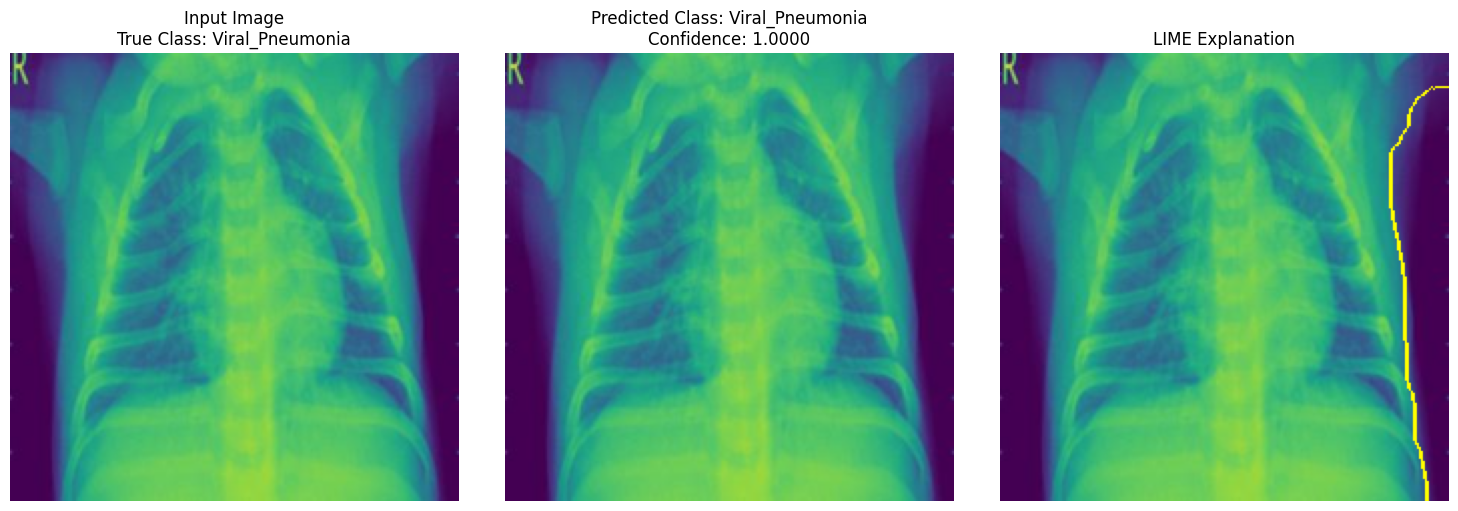

Saved LIME image: D:\liver\CViMXAI\results\Lung_XRay\lime\Lung_XRay_fold_4_image_3000_lime.png


100%|██████████| 1000/1000 [00:14<00:00, 70.68it/s]


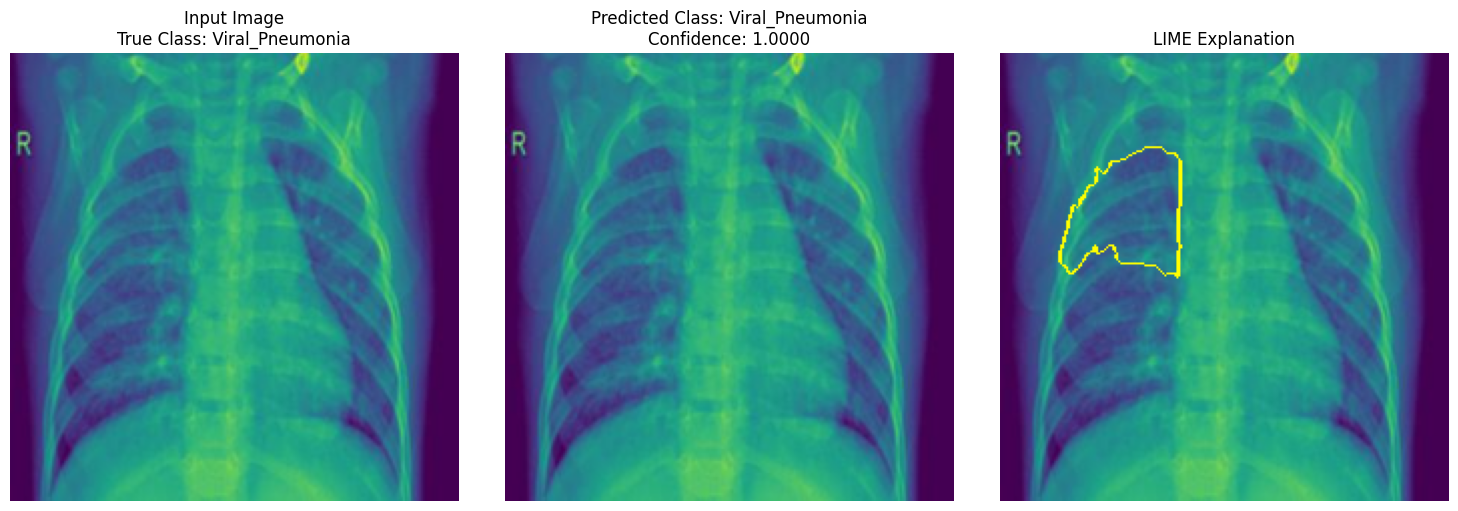

Saved LIME image: D:\liver\CViMXAI\results\Lung_XRay\lime\Lung_XRay_fold_4_image_3001_lime.png


100%|██████████| 1000/1000 [00:14<00:00, 70.88it/s]


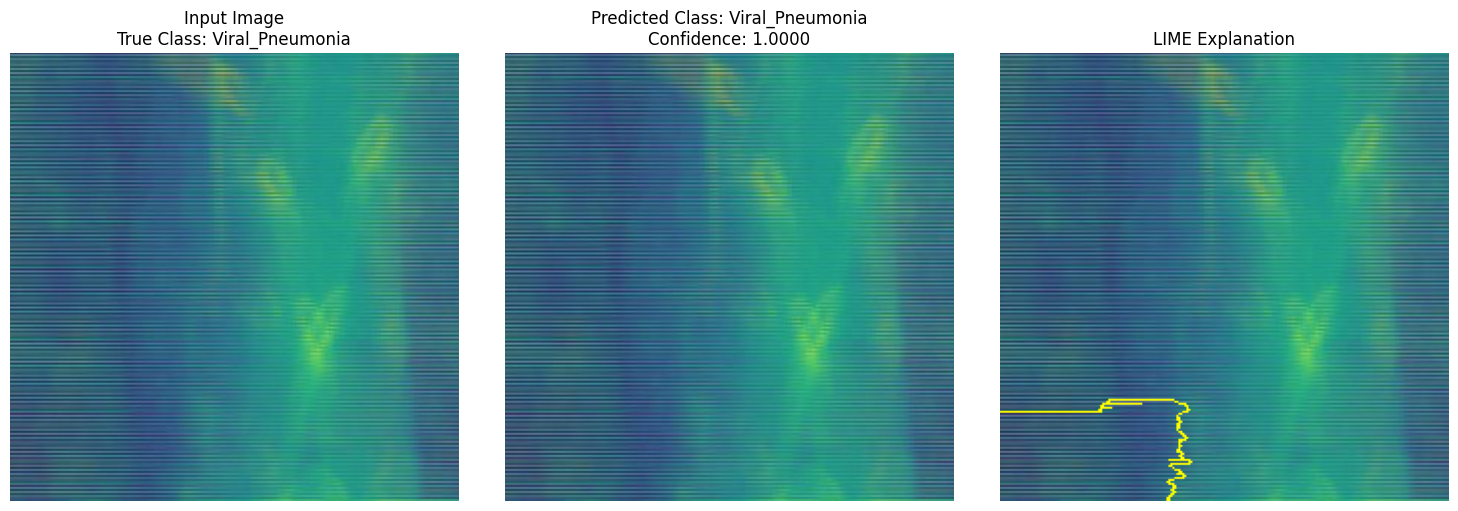

Saved LIME image: D:\liver\CViMXAI\results\Lung_XRay\lime\Lung_XRay_fold_4_image_3002_lime.png


100%|██████████| 1000/1000 [00:14<00:00, 71.26it/s]


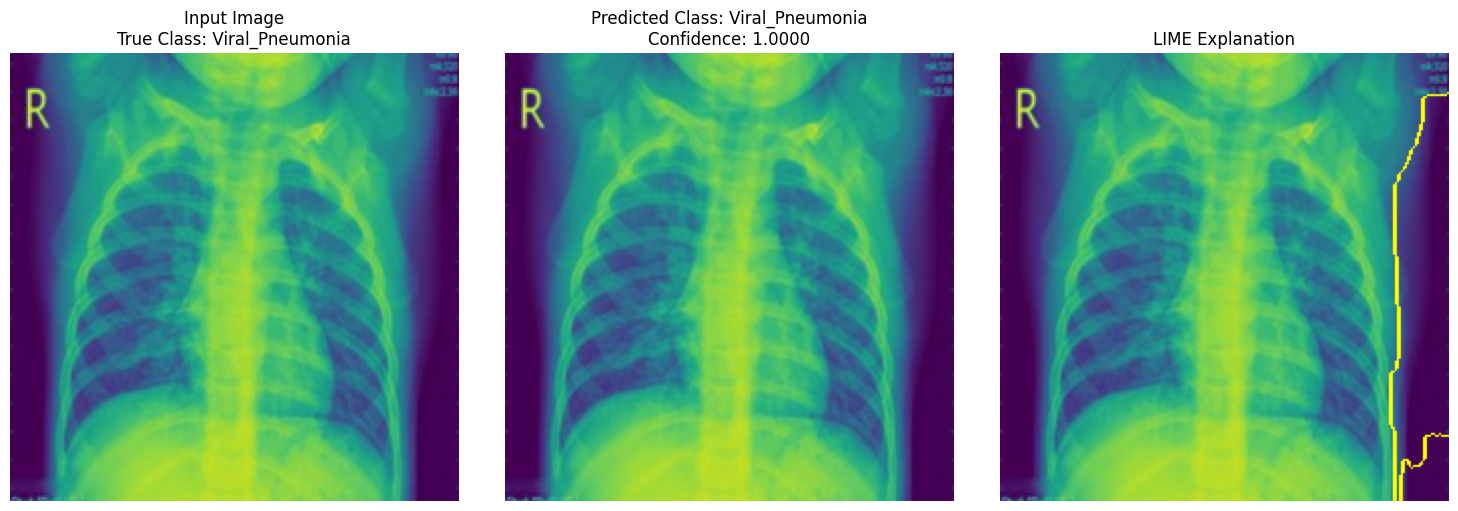

Saved LIME image: D:\liver\CViMXAI\results\Lung_XRay\lime\Lung_XRay_fold_4_image_3003_lime.png


100%|██████████| 1000/1000 [00:14<00:00, 70.49it/s]


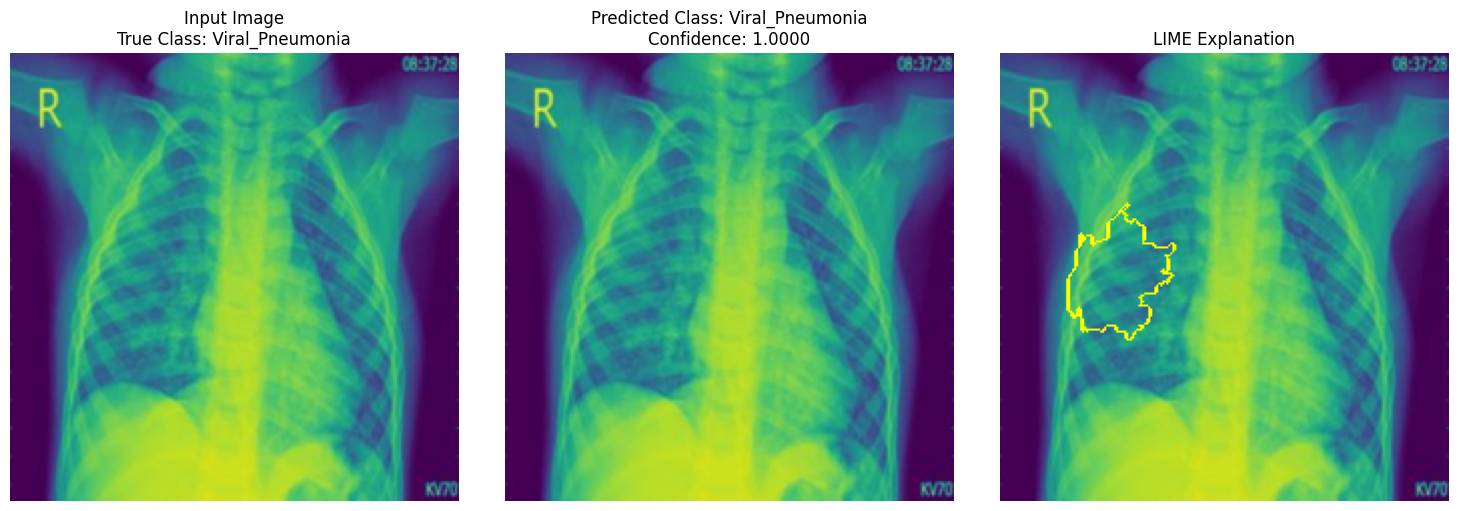

Saved LIME image: D:\liver\CViMXAI\results\Lung_XRay\lime\Lung_XRay_fold_4_image_3004_lime.png


In [ ]:
#Run LIME for Multiple Images
#for idx in [6, 1000, 300]:
for idx in range(2000,2005):
    explain_with_lime(
        image_index=idx,
        num_samples=1000,
        num_features=1
    )